In [10]:

import pandas as pd
import numpy as np
import requests
from io import StringIO
import matplotlib.pyplot as plt
import os

In [ ]:
# Clé API + URL
from dotenv import load_dotenv
load_dotenv()

API_KEY = os.getenv("EODHD_API_KEY")
if not API_KEY:
    raise ValueError("EODHD_API_KEY non defini - renseigne-le dans ton .env (voir .env.example).")

symbol = "SPXL.US"
url = f"https://eodhistoricaldata.com/api/eod/{symbol}?api_token={API_KEY}&period=d&fmt=csv"

# Créer le dossier
os.makedirs("../data/processed", exist_ok=True)

# Requête HTTP
response = requests.get(url)

if response.status_code == 200:
    # Lire le CSV avec la bonne colonne de date
    df = pd.read_csv(StringIO(response.text), parse_dates=["Date"])
    df.set_index("Date", inplace=True)
    df = df.sort_index()

    # Calcul des rendements log
    df['log_returns'] = np.log(df['Adjusted_close'] / df['Adjusted_close'].shift(1))
    df.dropna(inplace=True)

    # Sauvegarde
    df.to_csv("../data/processed/spxl_returns.csv")
    print(" Données de SPXL.US téléchargées et sauvegardées.")
    print(df.head())
else:
    print(" Erreur HTTP:", response.status_code)
    print("Message:", response.text)

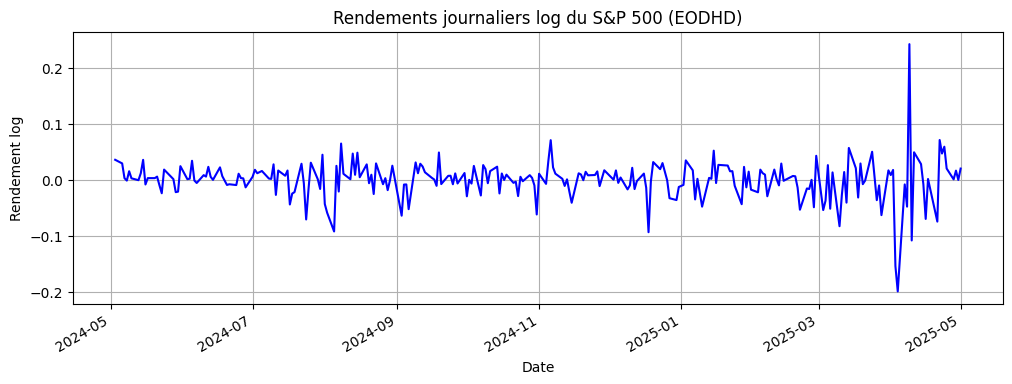

In [14]:
plt.figure(figsize=(12, 4))
df['log_returns'].plot(title="Rendements journaliers log du S&P 500 (EODHD)", color="blue")
plt.xlabel("Date")
plt.ylabel("Rendement log")
plt.grid(True)
plt.show()
